<a href="https://colab.research.google.com/github/Manawariqbal/Data-science-code/blob/main/Random_Forest_Implemenation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#step 1 import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#step 2 import the data set
df=pd.read_csv('loan_approval_random_forest.csv')
df.head()
df.tail()

,customer_id,age,annual_income,employment_years,employment_type,education,marital_status,city_tier,credit_score,existing_loans,loan_amount,loan_term_months,loan_approved
603,CUST1003,39,68356.38,2,Salaried,High School,Single,Tier 2,633.0,2,19627.73,48,1
604,CUST1004,38,97372.82,15,Salaried,Master,Married,Tier 2,645.0,1,72662.25,24,0
605,CUST1005,59,18000.00,11,Self-Employed,High School,Single,Tier 1,683.0,1,20195.49,24,0
606,CUST1006,22,59789.29,4,Salaried,High School,Married,Tier 1,654.0,0,12273.50,36,1
607,CUST1007,51,68883.27,14,Self-Employed,Master,Married,Tier 2,769.0,2,38540.92,12,1


**EDA**


In [ ]:
#step 3 check the dataset shape
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       608 non-null    object 
 1   age               608 non-null    int64  
 2   annual_income     590 non-null    float64
 3   employment_years  608 non-null    int64  
 4   employment_type   593 non-null    object 
 5   education         596 non-null    object 
 6   marital_status    608 non-null    object 
 7   city_tier         608 non-null    object 
 8   credit_score      596 non-null    float64
 9   existing_loans    608 non-null    int64  
 10  loan_amount       608 non-null    float64
 11  loan_term_months  608 non-null    int64  
 12  loan_approved     608 non-null    int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 61.9+ KB


,age,annual_income,employment_years,credit_score,existing_loans,loan_amount,loan_term_months,loan_approved
count,608.000000,590.000000,608.000000,596.000000,608.000000,608.000000,608.000000,608.000000
mean,41.518092,64450.902085,8.807566,679.117450,0.939145,40110.505280,37.934211,0.513158
std,13.889882,22005.273485,5.892290,85.918368,0.893643,23692.500745,14.334976,0.500238
min,18.000000,18000.000000,0.000000,370.000000,0.000000,3000.000000,12.000000,0.000000
25%,29.000000,49528.775000,4.000000,625.000000,0.000000,20600.080000,24.000000,0.000000
50%,41.000000,65195.415000,8.000000,681.500000,1.000000,36593.395000,36.000000,1.000000
75%,54.000000,79025.395000,13.000000,735.250000,1.000000,55382.227500,48.000000,1.000000
max,65.000000,134934.780000,21.000000,850.000000,3.000000,121414.900000,60.000000,1.000000


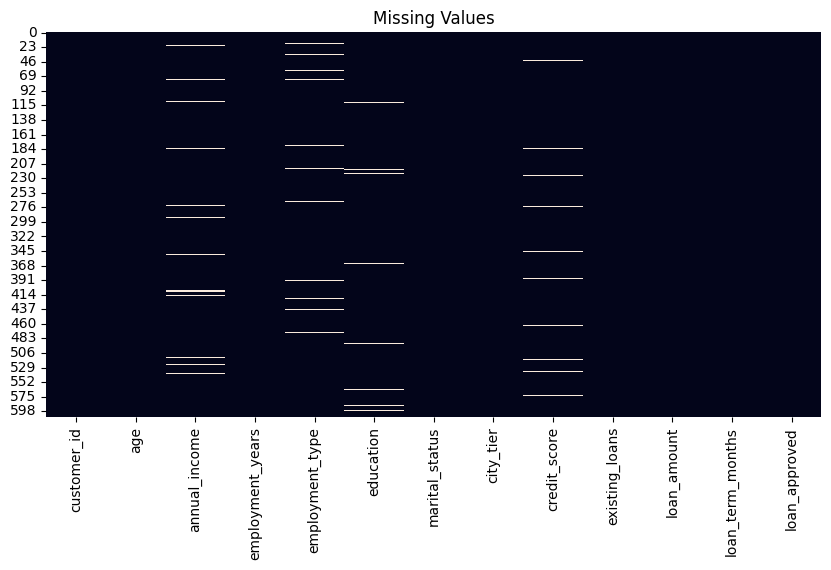

In [ ]:
#EDA part 2
#check null values
df.isnull().sum()


plt.figure(figsize=(10,5))
sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")
plt.show()

In [ ]:
#duplicate rows
df.duplicated().sum()

#remove duplicate
df=df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

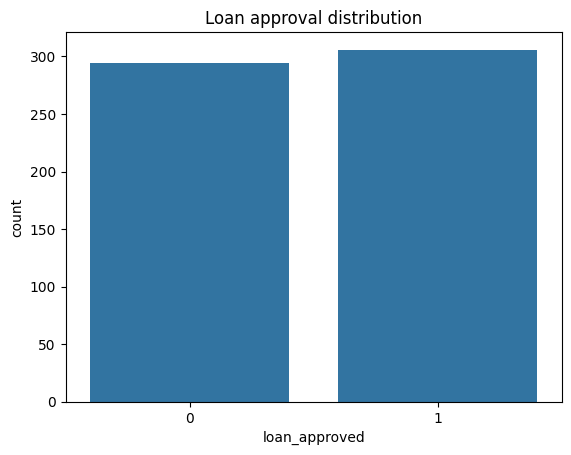

In [ ]:
#EDA 3: Target variable Analysis
df["loan_approved"].value_counts()
#visualize the target
sns.countplot(
    data=df,
    x="loan_approved"
)
plt.title("Loan approval distribution")
plt.show()

In [ ]:
#EDA part 4 Univariate Analysis
df.head()
#numerical features
numerical_columns=df.select_dtypes(
    include=np.number
).columns
numerical_columns


#Remove the target
numerical_columns=numerical_columns.drop("loan_approved")
numerical_columns

Index(['age', 'annual_income', 'employment_years', 'credit_score',
       'existing_loans', 'loan_amount', 'loan_term_months'],
      dtype='object')

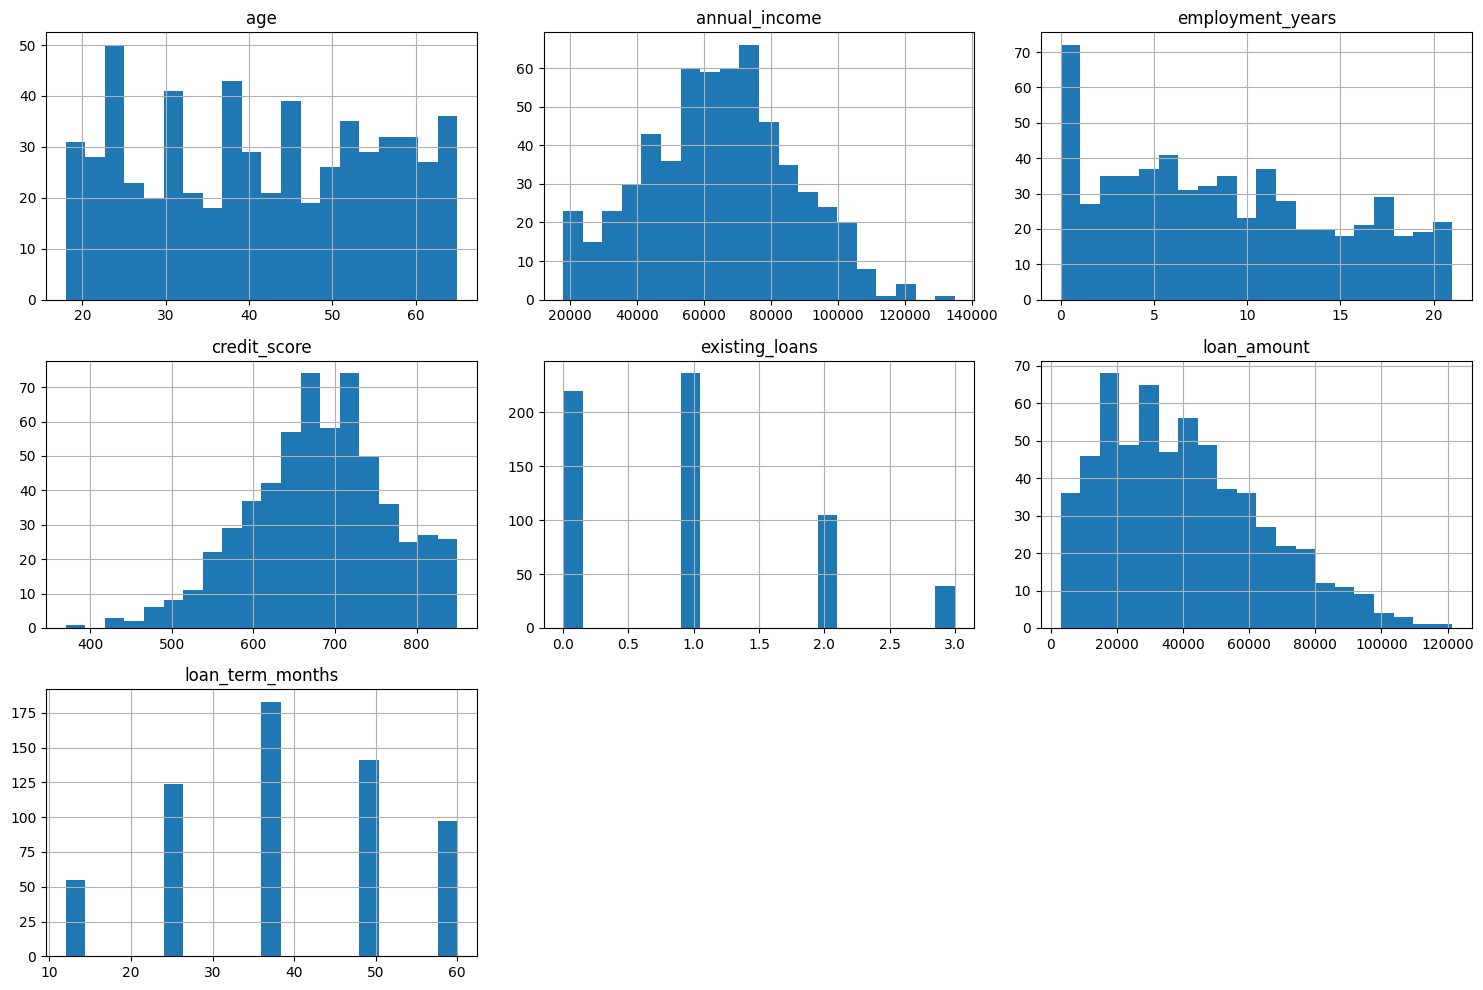

In [ ]:
#Histogram
df[numerical_columns].hist(
    figsize=(15,10),
    bins=20

)
plt.tight_layout()
plt.show()

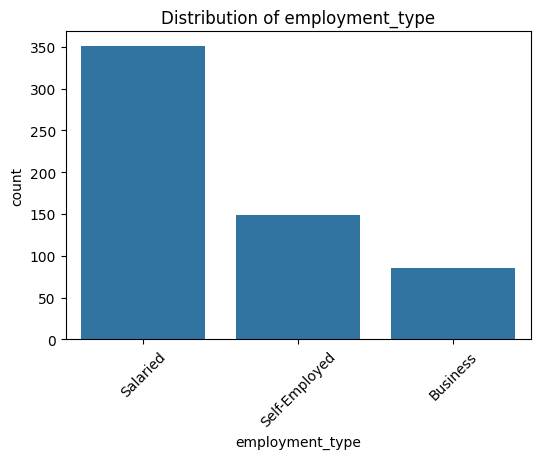

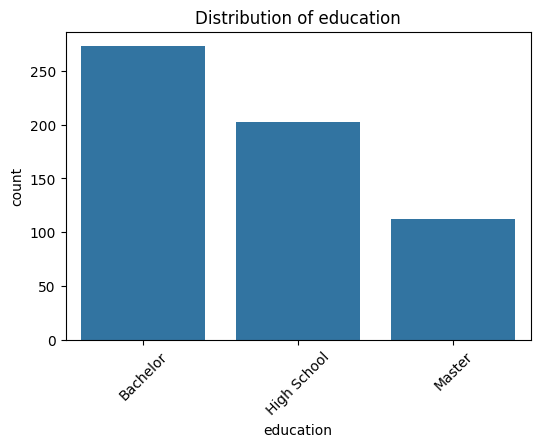

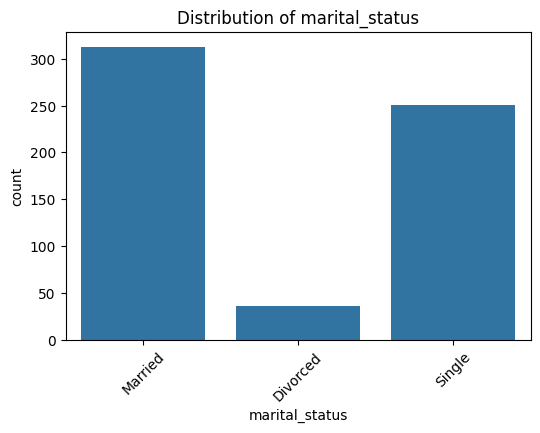

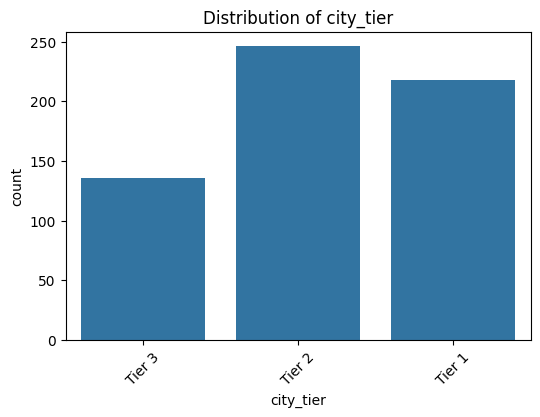

In [ ]:
#Categorical Features analysis
categorical_features=df.select_dtypes(
    include="object"
).columns
categorical_features
categorical_features=categorical_features.drop("customer_id")
categorical_features

#visualize the categorical features
for column in categorical_features:
  plt.figure(figsize=(6,4))
  sns.countplot(
      data=df,
      x=column
  )
  plt.title(f"Distribution of {column}")
  plt.xticks(rotation=45)
  plt.show()

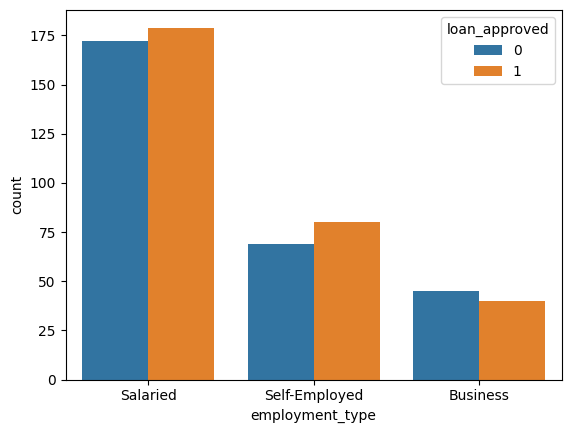

In [ ]:
#Bivariate Analysis
sns.countplot(
    data=df,
    x="employment_type",
    hue="loan_approved"
)
plt.show()

In [ ]:
#Correlation Analysis
numeric_df=df.select_dtypes(include=np.number)

correlation=numeric_df.corr()
correlation

,age,annual_income,employment_years,credit_score,existing_loans,loan_amount,loan_term_months,loan_approved
age,1.000000,0.080667,0.369512,0.055323,0.006449,0.062179,0.008155,-0.001700
annual_income,0.080667,1.000000,0.070602,-0.074690,-0.020986,0.543082,0.043959,0.039409
employment_years,0.369512,0.070602,1.000000,0.010794,0.025227,0.027581,0.038619,0.005101
credit_score,0.055323,-0.074690,0.010794,1.000000,0.049537,-0.034767,0.003643,0.025274
existing_loans,0.006449,-0.020986,0.025227,0.049537,1.000000,-0.054988,-0.085562,-0.258029
loan_amount,0.062179,0.543082,0.027581,-0.034767,-0.054988,1.000000,0.019776,-0.540992
loan_term_months,0.008155,0.043959,0.038619,0.003643,-0.085562,0.019776,1.000000,0.034863
loan_approved,-0.001700,0.039409,0.005101,0.025274,-0.258029,-0.540992,0.034863,1.000000


In [ ]:
#Prepare data for Machine Learning
df.columns
df=df.drop(
    columns=["customer_id"]
)
df.head()

,age,annual_income,employment_years,employment_type,education,marital_status,city_tier,credit_score,existing_loans,loan_amount,loan_term_months,loan_approved
0,22,58572.23,4,Salaried,Bachelor,Married,Tier 3,467.0,2,19840.00,24,1
1,55,62723.26,3,Salaried,Bachelor,Married,Tier 3,535.0,0,28410.78,48,1
2,49,59456.50,4,Salaried,Bachelor,Divorced,Tier 2,609.0,0,18258.54,36,1
3,39,68356.38,2,Salaried,High School,Single,Tier 2,633.0,2,19627.73,48,1
4,38,97372.82,15,Salaried,Master,Married,Tier 2,645.0,1,72662.25,24,0


In [ ]:
X=df.drop(
    columns=["loan_approved"]
)
y=df["loan_approved"]

X.head()
y.head()

,loan_approved
0,1
1,1
2,1
3,1
4,0


In [ ]:
#Train test split

X_train,X_test,y_train,y_test=train_test_split(X,y,
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=y
                                               )


In [ ]:
#Encoding and missing value Handling

numerical_features=X.select_dtypes(
    include=np.number
).columns.to_list()

categorical_features=X.select_dtypes(
    include="object"
).columns.to_list()
numerical_features
categorical_features

['employment_type', 'education', 'marital_status', 'city_tier']

In [ ]:
#Pipline for numerical values


numerical_transformer=Pipeline(
    steps=[
        (
        "imputer",
        SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]


)

In [ ]:
#Pipeline for categorical values

categorical_transformer=Pipeline(
    steps=[
        (
        "imputer",
        SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]


)



In [ ]:
#Combine preprocessing

preprocessor=ColumnTransformer(
    transformers=[
        (
        "num",
        numerical_transformer,
        numerical_features),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [ ]:
X.head()

,age,annual_income,employment_years,employment_type,education,marital_status,city_tier,credit_score,existing_loans,loan_amount,loan_term_months
0,22,58572.23,4,Salaried,Bachelor,Married,Tier 3,467.0,2,19840.00,24
1,55,62723.26,3,Salaried,Bachelor,Married,Tier 3,535.0,0,28410.78,48
2,49,59456.50,4,Salaried,Bachelor,Divorced,Tier 2,609.0,0,18258.54,36
3,39,68356.38,2,Salaried,High School,Single,Tier 2,633.0,2,19627.73,48
4,38,97372.82,15,Salaried,Master,Married,Tier 2,645.0,1,72662.25,24


In [ ]:
# Create your model
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
#Create complete pipeline
#preprocession+Random Forest

model=Pipeline(
    steps=[

           ("preprocessor",
            preprocessor),
           (
               "random_forest",
               rf_model
           )
    ]
)



In [ ]:
#Train the model
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'annual_income',
                                                   'employment_years',
                                                   'credit_score',
                                                   'existing_loans',
                                                   'loan_amount',
                                                   'loan_term_months']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['employment_type',
                                                   'education',
                                                   'marital_status',
                                                   'city_tier'])])),
                ('random_forest', RandomForestClassifier(random_state=42))])